In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset
from sklearn import svm
from sklearn.metrics import accuracy_score
import time
import pandas as pd
import numpy as np

#Random Seed for Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def get_dataloaders(dataset_name, batch_size, pin_memory=False):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    if dataset_name == 'MNIST':
        train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_full = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    elif dataset_name == 'FashionMNIST':
        train_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_full = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # Combine to split manually 70-10-20
    full_dataset = ConcatDataset([train_full, test_full])
    total_size = len(full_dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.1 * total_size)
    test_size = total_size - train_size - val_size

    train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)

    return train_loader, val_loader, test_loader

In [ ]:
def get_resnet_model(model_name, num_classes=10):
    if model_name == 'resnet18':
        model = torchvision.models.resnet18(pretrained=False)
    elif model_name == 'resnet50':
        model = torchvision.models.resnet50(pretrained=False)

    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Modify final layer for 10 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, epochs, device, use_amp=True):
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    model.to(device)

    best_acc = 0.0

    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        # Validation
        val_acc = evaluate_model(model, val_loader, device)
        # print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc

    return best_acc

def evaluate_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [ ]:
target_dataset = 'FashionMNIST'
configs = [
    # (Model, Batch, Optim, LR)
    ('resnet18', 16, 'SGD', 0.001),
    ('resnet50', 16, 'SGD', 0.001),
    ('resnet18', 16, 'SGD', 0.0001),
    ('resnet50', 16, 'SGD', 0.0001),
    ('resnet18', 16, 'Adam', 0.001),
    ('resnet50', 16, 'Adam', 0.001),
    ('resnet18', 16, 'Adam', 0.0001),
    ('resnet50', 16, 'Adam', 0.0001),
    ('resnet18', 32, 'SGD', 0.001),
    ('resnet50', 32, 'SGD', 0.001),
     ('resnet18', 32, 'Adam', 0.0001),
    ('resnet50', 32, 'Adam', 0.0001),
]

results_q1a = []
EPOCHS = 3 # 3 gave valid experiments (>80%) acc might get increased on increasing no of epochs

print(f"Running Experiments for Q1(a) on {target_dataset}")
print("-" * 60)

for conf in configs:
    model_name, batch_size, opt_name, lr = conf

    # Load Data
    train_loader, val_loader, test_loader = get_dataloaders(target_dataset, batch_size, pin_memory=True)

    # Init Model
    model = get_resnet_model(model_name)

    # Init Optimizer
    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train
    print(f"Training {model_name} | BS: {batch_size} | Opt: {opt_name} | LR: {lr}")
    train_model(model, train_loader, val_loader, optimizer, EPOCHS, device, use_amp=True)

    # Test
    test_acc = evaluate_model(model, test_loader, device)
    print(f"Result: {test_acc:.2f}%")

    results_q1a.append({
        "Model": model_name,
        "Batch Size": batch_size,
        "Optimizer": opt_name,
        "LR": lr,
        "Test Acc": test_acc
    })

# Display Results Table
df_q1a = pd.DataFrame(results_q1a)
print("\nQ1(a) Final Results Table:")
print(df_q1a)

Running Experiments for Q1(a) on FashionMNIST
------------------------------------------------------------


100.0%
100.0%
100.0%
100.0%
/home/b23cs1037/DN/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/b23cs1037/DN/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Training resnet18 | BS: 16 | Opt: SGD | LR: 0.001


/tmp/ipykernel_3263026/4009943762.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Starting training on cuda...


/tmp/ipykernel_3263026/4009943762.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Result: 91.43%
Training resnet50 | BS: 16 | Opt: SGD | LR: 0.001
Starting training on cuda...
Result: 89.84%
Training resnet18 | BS: 16 | Opt: SGD | LR: 0.0001
Starting training on cuda...
Result: 85.28%
Training resnet50 | BS: 16 | Opt: SGD | LR: 0.0001
Starting training on cuda...
Result: 78.17%
Training resnet18 | BS: 16 | Opt: Adam | LR: 0.001
Starting training on cuda...
Result: 91.61%
Training resnet50 | BS: 16 | Opt: Adam | LR: 0.001
Starting training on cuda...
Result: 91.09%
Training resnet18 | BS: 16 | Opt: Adam | LR: 0.0001
Starting training on cuda...
Result: 92.26%
Training resnet50 | BS: 16 | Opt: Adam | LR: 0.0001
Starting training on cuda...
Result: 91.79%
Training resnet18 | BS: 32 | Opt: SGD | LR: 0.001
Starting training on cuda...
Result: 90.17%
Training resnet50 | BS: 32 | Opt: SGD | LR: 0.001
Starting training on cuda...
Result: 88.23%

Q1(a) Final Results Table:
      Model  Batch Size Optimizer      LR   Test Acc
0  resnet18          16       SGD  0.0010  91.4285

In [ ]:
target_dataset = 'MNIST' # Change to 'MNIST' if needed
configs = [
    # (Model, Batch, Optim, LR)
    ('resnet18', 16, 'SGD', 0.001),
    ('resnet50', 16, 'SGD', 0.001),
    ('resnet18', 16, 'SGD', 0.0001),
    ('resnet50', 16, 'SGD', 0.0001),
    ('resnet18', 16, 'Adam', 0.001),
    ('resnet50', 16, 'Adam', 0.001),
    ('resnet18', 16, 'Adam', 0.0001),
    ('resnet50', 16, 'Adam', 0.0001),
    ('resnet18', 32, 'SGD', 0.001),
    ('resnet50', 32, 'SGD', 0.001),
    ('resnet18', 32, 'Adam', 0.0001),
    ('resnet50', 32, 'Adam', 0.0001),

]

results_q1a = []
EPOCHS = 3

print(f"Running Experiments for Q1(a) on {target_dataset}")
print("-" * 60)

for conf in configs:
    model_name, batch_size, opt_name, lr = conf

    # Load Data
    train_loader, val_loader, test_loader = get_dataloaders(target_dataset, batch_size, pin_memory=True)

    # Init Model
    model = get_resnet_model(model_name)

    # Init Optimizer
    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train
    print(f"Training {model_name} | BS: {batch_size} | Opt: {opt_name} | LR: {lr}")
    train_model(model, train_loader, val_loader, optimizer, EPOCHS, device, use_amp=True)

    # Test
    test_acc = evaluate_model(model, test_loader, device)
    print(f"Result: {test_acc:.2f}%")

    results_q1a.append({
        "Model": model_name,
        "Batch Size": batch_size,
        "Optimizer": opt_name,
        "LR": lr,
        "Test Acc": test_acc
    })

# Display Results Table
df_q1a = pd.DataFrame(results_q1a)
print("\nQ1(a) Final Results Table:")
print(df_q1a)

Running Experiments for Q1(a) on MNIST
------------------------------------------------------------


/home/b23cs1037/DN/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/b23cs1037/DN/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_3263026/4009943762.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Training resnet18 | BS: 16 | Opt: SGD | LR: 0.001
Starting training on cuda...


/tmp/ipykernel_3263026/4009943762.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Result: 99.01%
Training resnet50 | BS: 16 | Opt: SGD | LR: 0.001
Starting training on cuda...
Result: 98.89%
Training resnet18 | BS: 16 | Opt: SGD | LR: 0.0001
Starting training on cuda...
Result: 97.15%
Training resnet50 | BS: 16 | Opt: SGD | LR: 0.0001
Starting training on cuda...
Result: 96.09%
Training resnet18 | BS: 16 | Opt: Adam | LR: 0.001
Starting training on cuda...
Result: 98.70%
Training resnet50 | BS: 16 | Opt: Adam | LR: 0.001
Starting training on cuda...
Result: 97.20%
Training resnet18 | BS: 16 | Opt: Adam | LR: 0.0001
Starting training on cuda...
Result: 99.29%
Training resnet50 | BS: 16 | Opt: Adam | LR: 0.0001
Starting training on cuda...
Result: 99.26%
Training resnet18 | BS: 32 | Opt: SGD | LR: 0.001
Starting training on cuda...
Result: 98.96%
Training resnet50 | BS: 32 | Opt: SGD | LR: 0.001
Starting training on cuda...
Result: 98.42%

Q1(a) Final Results Table:
      Model  Batch Size Optimizer      LR   Test Acc
0  resnet18          16       SGD  0.0010  99.0142

In [ ]:
def run_svm(kernel_type, dataset_name):
    print(f"Running SVM ({kernel_type}) on {dataset_name}...")

    # Load raw data
    if dataset_name == 'MNIST':
        train_data = torchvision.datasets.MNIST(root='./data', train=True, download=True)
        test_data = torchvision.datasets.MNIST(root='./data', train=False, download=True)
    else:
        train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
        test_data = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

    # Flatten data: (N, 28, 28) -> (N, 784)
    X_train = train_data.data.numpy().reshape(-1, 28*28) / 255.0
    y_train = train_data.targets.numpy()
    X_test = test_data.data.numpy().reshape(-1, 28*28) / 255.0
    y_test = test_data.targets.numpy()


    clf = svm.SVC(kernel=kernel_type)

    start_time = time.time()
    clf.fit(X_train, y_train)
    end_time = time.time()

    train_time_ms = (end_time - start_time) * 1000

    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred) * 100

    return acc, train_time_ms

# Run Q1(b)
print("\n--- Q1(b) SVM Results ---")
for ds in ['MNIST', 'FashionMNIST']:
    for k in ['poly', 'rbf']:
        acc, t_time = run_svm(k, ds)
        print(f"Dataset: {ds} | Kernel: {k} | Acc: {acc:.2f}% | Time: {t_time:.0f} ms")


--- Q1(b) SVM Results ---
Running SVM (poly) on MNIST...
Dataset: MNIST | Kernel: poly | Acc: 97.71% | Time: 181106 ms
Running SVM (rbf) on MNIST...
Dataset: MNIST | Kernel: rbf | Acc: 97.92% | Time: 167134 ms
Running SVM (poly) on FashionMNIST...
Dataset: FashionMNIST | Kernel: poly | Acc: 86.30% | Time: 283958 ms
Running SVM (rbf) on FashionMNIST...
Dataset: FashionMNIST | Kernel: rbf | Acc: 88.28% | Time: 232496 ms


In [ ]:
import setuptools.dist
from thop import profile

In [ ]:
def get_flops(model, input_sample):
    # Calculate MACs (Multiply-Accumulate Operations)
    macs, params = profile(model, inputs=(input_sample, ), verbose=False)
    # FLOPs is roughly 2 * MACs
    return macs * 2

def run_q2_experiment(device_type):
    target_device = torch.device("cuda" if device_type == "GPU" and torch.cuda.is_available() else "cpu")
    print(f"\nRunning Q2 Experiments on {target_device}...")

    # Fixed Config for Comparison
    batch_size = 16
    lr = 0.001
    optimizer_name = 'SGD' # or Adam
    epochs = 3

    train_loader, val_loader, test_loader = get_dataloaders('FashionMNIST', batch_size)

    results = []

    for model_name in ['resnet18', 'resnet50']:
        model = get_resnet_model(model_name)
        model.to(target_device)

        # Calculate FLOPs (only need to do once, but doing here for flow)
        dummy_input = torch.randn(1, 1, 28, 28).to(target_device)
        flops = get_flops(model, dummy_input)

        # Init Optim
        optimizer = optim.SGD(model.parameters(), lr=lr)

        # Measure Train Time
        start_time = time.time()
        # Train 1 epoch for timing
        train_model(model, train_loader, val_loader, optimizer, epochs, target_device, use_amp=False)
        end_time = time.time()

        total_time_ms = (end_time - start_time) * 1000

        # Acc
        acc = evaluate_model(model, test_loader, target_device)

        results.append({
            "Device": device_type,
            "Model": model_name,
            "Train Time (ms)": total_time_ms,
            "FLOPs": flops,
            "Test Acc": acc
        })
        print(f"{model_name} on {device_type} done. Time: {total_time_ms:.0f}ms")

    return results

# Run Q2
results_gpu = run_q2_experiment("GPU")
results_cpu = run_q2_experiment("CPU") # This will be slow for ResNet50!

df_q2 = pd.DataFrame(results_gpu + results_cpu)
print("\nQ2 Final Comparison Table:")
print(df_q2)


Running Q2 Experiments on cuda...


/home/b23cs1037/DN/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/b23cs1037/DN/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_3263026/4009943762.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_3263026/4009943762.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Starting training on cuda...
resnet18 on GPU done. Time: 73544ms
Starting training on cuda...
resnet50 on GPU done. Time: 153237ms

Running Q2 Experiments on cpu...
Starting training on cpu...
resnet18 on CPU done. Time: 656216ms
Starting training on cpu...
resnet50 on CPU done. Time: 1478222ms

Q2 Final Comparison Table:
  Device     Model  Train Time (ms)        FLOPs   Test Acc
0    GPU  resnet18     7.354353e+04   66368000.0  86.378571
1    GPU  resnet50     1.532369e+05  157510144.0  82.750000
2    CPU  resnet18     6.562164e+05   66368000.0  85.521429
3    CPU  resnet50     1.478222e+06  157510144.0  81.864286


/home/b23cs1037/DN/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/b23cs1037/DN/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Training Best Model (ResNet18 on MNIST)...
Epoch 1/5 | Train Loss: 0.1265 | Val Loss: 0.0453 | Val Acc: 98.69%
Epoch 2/5 | Train Loss: 0.0376 | Val Loss: 0.0449 | Val Acc: 98.63%
Epoch 3/5 | Train Loss: 0.0305 | Val Loss: 0.0276 | Val Acc: 99.16%
Epoch 4/5 | Train Loss: 0.0234 | Val Loss: 0.0270 | Val Acc: 99.29%
Epoch 5/5 | Train Loss: 0.0186 | Val Loss: 0.0214 | Val Acc: 99.30%
Model saved as 'best_model.pth'
Graph saved as 'train_val_graphs.png'


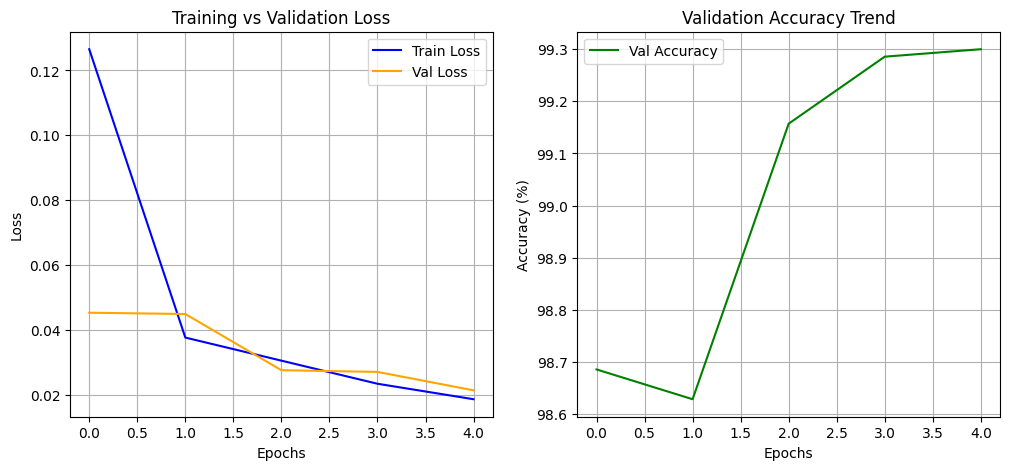

Final Test Accuracy of Best Model: 99.10%


In [ ]:
import matplotlib.pyplot as plt

model = torchvision.models.resnet18(pretrained=False)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False) # Fix for MNIST 1 channel
model.fc = nn.Linear(model.fc.in_features, 10) # Fix for 10 classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# --- 3. Training Loop with History Tracking ---
train_losses = []
val_losses = []
val_accuracies = []
epochs = 5

print("Training Best Model (ResNet18 on MNIST)...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * correct / total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

# --- 4. Save the Model ---
torch.save(model.state_dict(), 'best_model.pth')
print("Model saved as 'best_model.pth'")

# --- 5. Generate and Save Graphs ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Trend')
plt.legend()
plt.grid(True)

plt.savefig('train_val_graphs.png')
print("Graph saved as 'train_val_graphs.png'")
plt.show()

# --- 6. Final Test Accuracy ---
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Final Test Accuracy of Best Model: {100 * correct / total:.2f}%")